# Rossmann Store Sales — Forecasting Models & Evaluation

**Goal:** Train XGBoost on the engineered features from notebook 02, compare against the naive
baselines, and optionally try Facebook Prophet on a single store for a classic time-series
comparison point.

Sections:
1. Rebuild data pipeline (load, clean, feature engineer, split)
2. Train XGBoost
3. Evaluate against naive baselines
4. Feature importance
5. Optional: Prophet on a single store
6. Model comparison table
7. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

## 1. Rebuild Data Pipeline

Same steps as notebook 02, repeated here so this notebook can run independently.

In [2]:
train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[df['Open'] == 1].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

# Calendar features
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Lag features
for lag in [1, 7, 14]:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

# Rolling features (shifted so today's sales don't leak into today's feature)
for window in [7, 30]:
    df[f'Sales_rollmean_{window}'] = (
        df.groupby('Store')['Sales']
          .transform(lambda s: s.shift(1).rolling(window).mean())
    )

df = df.dropna(subset=['Sales_lag_14', 'Sales_rollmean_30']).reset_index(drop=True)

# Encode a few categoricals XGBoost needs as numeric
df['StoreType'] = df['StoreType'].astype('category').cat.codes
df['Assortment'] = df['Assortment'].astype('category').cat.codes
df['StateHoliday'] = df['StateHoliday'].astype('category').cat.codes

print(df.shape)

(810942, 27)


In [3]:
# Chronological split (same cutoffs as notebook 02 -- adjust if you changed them there)
train_cutoff = pd.Timestamp('2015-05-14')
valid_cutoff = pd.Timestamp('2015-06-25')

train_df = df[df['Date'] <= train_cutoff].copy()
valid_df = df[(df['Date'] > train_cutoff) & (df['Date'] <= valid_cutoff)].copy()
test_df = df[df['Date'] > valid_cutoff].copy()

print('Train:', train_df.shape, ' Valid:', valid_df.shape, ' Test:', test_df.shape)

Train: (737707, 27)  Valid: (38555, 27)  Test: (34680, 27)


## 2. Train XGBoost

Select feature columns, excluding identifiers, the target, and raw date fields the model can't
use directly (calendar features already capture the useful signal from Date).

In [4]:
feature_cols = [
    'Store', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'IsWeekend',
    'Promo', 'SchoolHoliday', 'StateHoliday', 'StoreType', 'Assortment',
    'CompetitionDistance', 'Promo2',
    'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14',
    'Sales_rollmean_7', 'Sales_rollmean_30'
]
feature_cols = [c for c in feature_cols if c in df.columns]

X_train, y_train = train_df[feature_cols], train_df['Sales']
X_valid, y_valid = valid_df[feature_cols], valid_df['Sales']

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_valid)
print('XGBoost trained.')

XGBoost trained.


## 3. Evaluate Against Naive Baselines

Recompute the naive baselines here so everything is compared in one place.

In [5]:
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rmspe_val = rmspe(y_true, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'RMSPE': rmspe_val}


results = []
results.append(evaluate('Naive: same day last week', valid_df['Sales'], valid_df['Sales_lag_7']))
results.append(evaluate('Naive: 7-day rolling avg', valid_df['Sales'], valid_df['Sales_rollmean_7']))
results.append(evaluate('XGBoost', y_valid, xgb_pred))

results_df = pd.DataFrame(results).set_index('Model').round(1)
results_df

,RMSE,MAE,RMSPE
Model,,,
Naive: same day last week,2758.8,2155.1,0.5
Naive: 7-day rolling avg,2003.9,1482.8,0.3
XGBoost,1097.1,848.3,0.2


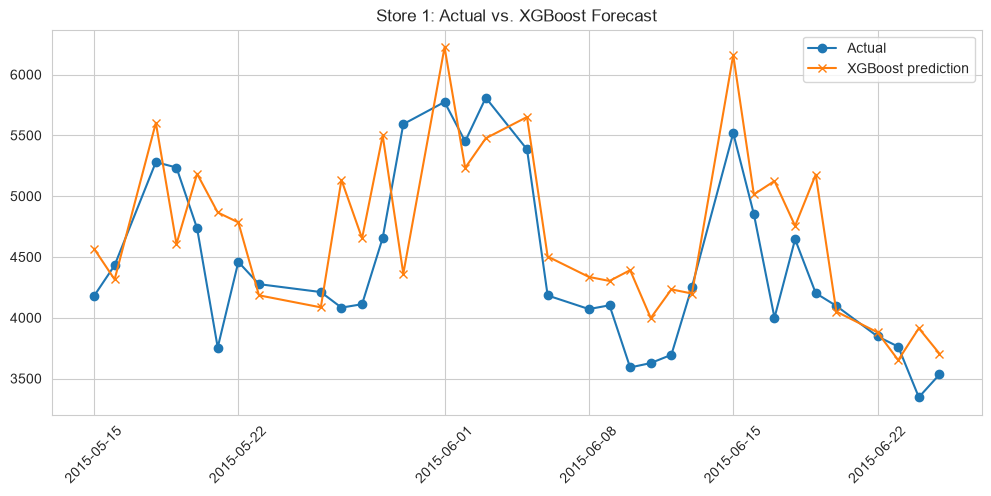

In [6]:
# Visual check: actual vs XGBoost prediction for one store
sample_store = valid_df['Store'].iloc[0]
mask = valid_df['Store'] == sample_store
sample_dates = valid_df.loc[mask, 'Date']

plt.plot(sample_dates, valid_df.loc[mask, 'Sales'].values, label='Actual', marker='o')
plt.plot(sample_dates, xgb_pred[mask.values], label='XGBoost prediction', marker='x')
plt.title(f'Store {sample_store}: Actual vs. XGBoost Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 4. Feature Importance

Which features is XGBoost actually relying on? Lag/rolling features usually dominate, that's
expected and fine, but it's worth checking whether Promo and calendar features also register.

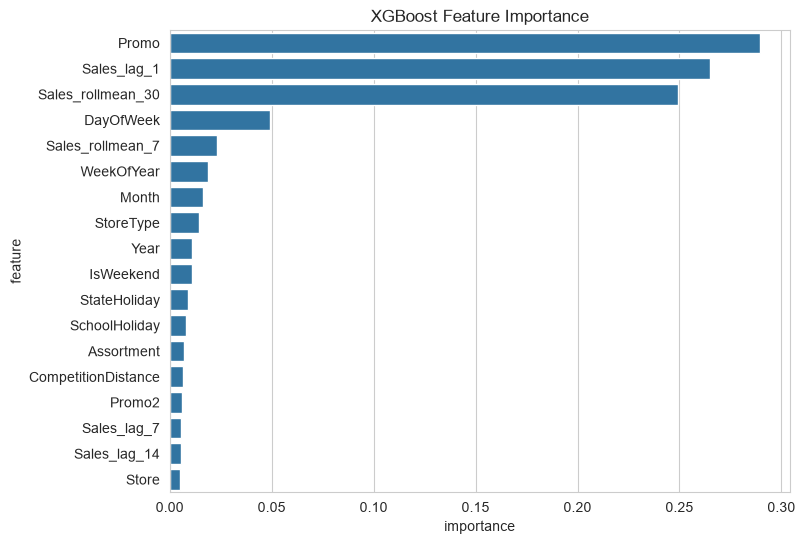

,feature,importance
6,Promo,0.289605
13,Sales_lag_1,0.265048
17,Sales_rollmean_30,0.249286
1,DayOfWeek,0.049342
16,Sales_rollmean_7,0.023224
4,WeekOfYear,0.018620
2,Month,0.016258
9,StoreType,0.014251
3,Year,0.011019
5,IsWeekend,0.010960


In [7]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('XGBoost Feature Importance')
plt.show()

importance_df

## 5. Optional: Prophet on a Single Store

Prophet is a classic time-series-specific tool (as opposed to XGBoost's tabular-with-lags
approach). It only forecasts one series at a time, so this section demonstrates it on a single
store as a comparison point, not as a full replacement for the XGBoost model above.

Skip this section if `prophet` was difficult to install, it's optional and doesn't block the
rest of the project.

In [8]:
# from prophet import Prophet
#
# store_id = valid_df['Store'].iloc[0]
# store_history = df[df['Store'] == store_id][['Date', 'Sales']].rename(
#     columns={'Date': 'ds', 'Sales': 'y'}
# )
#
# prophet_train = store_history[store_history['ds'] <= train_cutoff]
# prophet_valid = store_history[(store_history['ds'] > train_cutoff) & (store_history['ds'] <= valid_cutoff)]
#
# m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
# m.fit(prophet_train)
#
# future = prophet_valid[['ds']]
# forecast = m.predict(future)
#
# prophet_rmspe = rmspe(prophet_valid['y'].values, forecast['yhat'].values)
# print(f'Prophet RMSPE for store {store_id}: {prophet_rmspe:.3f}')
#
# m.plot(forecast)
# plt.title(f'Prophet Forecast — Store {store_id}')
# plt.show()

## 6. Model Comparison Table

This is the table to put in your README's Model Performance section.

In [9]:
results_df

,RMSE,MAE,RMSPE
Model,,,
Naive: same day last week,2758.8,2155.1,0.5
Naive: 7-day rolling avg,2003.9,1482.8,0.3
XGBoost,1097.1,848.3,0.2
